In [37]:
import torch
import torch.nn as nn
import timm  # Library for state-of-the-art image models
import pandas as pd
from pathlib import Path

In [38]:
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Device Name: NVIDIA GeForce RTX 3060 Laptop GPU


In [39]:
BASE_PATH = Path.cwd()
TRAIN_CSV_PATH: Path = BASE_PATH / "train.csv"
TEST_CSV_PATH: Path = BASE_PATH / "test.csv"
IMG_SIZE_CSV_PATH: Path = BASE_PATH / "img_size.csv"
TRAIN_IMG_PATH: Path = BASE_PATH / "train" / "train_raw" 
TEST_IMG_PATH: Path = BASE_PATH / "test" / "test_raw"

TRAIN_IMG_512: Path = BASE_PATH / "train" / "train_512"
TRAIN_IMG_512_BORDER: Path = BASE_PATH / "train" / "train_512_bordercrop"
TEST_IMG_512: Path = BASE_PATH / "test" / "test_512"
NUM_CLASSES = 14
MODEL_NAME = "efficientnet_b4_augmentation-affine-gamma08-gaussnoise_bordercrop"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [40]:
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes=14, pretrained=True):
        super(EfficientNetClassifier, self).__init__()
        
        # Load a pretrained EfficientNet backbone
        # 'pretrained=True' loads weights trained on ImageNet (millions of natural images)
        self.backbone = timm.create_model('efficientnet_b4', pretrained=pretrained)
        
        # EfficientNet-B4 outputs 1792 features before its final classification layer
        in_features = self.backbone.num_features
    
        # Replace the final classification head
        # We map those 1792 features directly to our 14 abnormality classes
        self.backbone.classifier = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        # Returns raw outputs (logits) for each of the 14 classes
        return self.backbone(x)

# 2. SwinCheX (Swin Transformer)[cite: 1]
class SwinClassifier(nn.Module):
    def __init__(self, num_classes=14, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('swin_base_patch4_window7_224', pretrained=pretrained, num_classes=num_classes)
        
    def forward(self, x):
        return self.backbone(x)

In [41]:
model_registry = {
    "efficientnet_b4": lambda: EfficientNetClassifier(num_classes=NUM_CLASSES),
    "swin": lambda: SwinClassifier(num_classes=NUM_CLASSES),
}

# Select target model architecture for execution
SELECTED_MODEL = "efficientnet_b4"
model = model_registry[SELECTED_MODEL]().to(DEVICE)
print(f"Loaded architecture: {SELECTED_MODEL}")

Loaded architecture: efficientnet_b4


In [42]:
from torch.utils.data import Dataset, DataLoader
import cv2 as cv
import numpy as np
from albumentations.core.transforms_interface import ImageOnlyTransform
import albumentations as A


def apply_clahe(image_gray, clip_limit=3.0, tile_grid_size=(8, 8)):

    if image_gray.dtype != np.uint8:
        image_gray = cv.normalize(image_gray, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

    clahe = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image_gray)


def apply_percentile_clip(image_gray, low_percentile=1, high_percentile=99):

    image_float = image_gray.astype(np.float32)

    p_low, p_high = np.percentile(image_float, [low_percentile, high_percentile])

    if p_high <= p_low:
        return image_gray if image_gray.dtype == np.uint8 else image_float.astype(np.uint8)

    image_clipped = np.clip(image_float, p_low, p_high)
    image_rescaled = (image_clipped - p_low) / (p_high - p_low) * 255.0

    return image_rescaled.astype(np.uint8)

class PercentileClip(ImageOnlyTransform):
    def __init__(self, low_percentile=1, high_percentile=99, always_apply=False, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.low_percentile = low_percentile
        self.high_percentile = high_percentile

    def apply(self, img, **params):
        return apply_percentile_clip(img, self.low_percentile, self.high_percentile)

    def get_transform_init_args_names(self):
        return ("low_percentile", "high_percentile")

class GammaCorrection(ImageOnlyTransform):
    def __init__(self, gamma=0.8, always_apply=False, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.gamma = gamma

    def apply(self, img, **params):
        return gamma_correction(img, self.gamma)

    def get_transform_init_args_names(self):
        return ("gamma")
    
def gamma_correction(image, gamma=1.2):

    image = image.astype(
        np.float32
    ) / 255.0

    image = np.power(
        image,
        gamma
    )

    image = (
        image * 255
    ).astype(np.uint8)

    return image

# def crop_black_border(image, threshold=10):
    
#     row_max = image.max(axis=1)
#     col_max = image.max(axis=0)

#     rows = np.where(row_max > threshold)[0]
#     cols = np.where(col_max > threshold)[0]

#     if len(rows) == 0 or len(cols) == 0:
#         return image  # img blk

#     y0, y1 = rows[0], rows[-1] + 1
#     x0, x1 = cols[0], cols[-1] + 1
#     return image[y0:y1, x0:x1]

In [43]:

train_transform = A.Compose([
    A.Affine(
        scale=(0.9, 1.1),
        rotate=(-10, 10),
        translate_percent=0.0,     
        interpolation=cv.INTER_LINEAR, 
        p=0.5,
    ),

    # PercentileClip(low_percentile=1, high_percentile=99, p=0.4),
    GammaCorrection(gamma=0.8, p=0.4),
    # A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.4),

    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
])

C:\Users\quimc\AppData\Local\Temp\ipykernel_7048\162353759.py:45: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


In [44]:

class ChestXrayDataset(Dataset):
    def __init__(
        self,
        df,
        img_dir,
        contrast_method=None,  # "clahe", "percentile", "gamma" o None
        transform=None,
        clahe_clip_limit=3.0,
        clahe_tile_grid=(8, 8),
        percentile_low=1,
        percentile_high=99,
        gamma=1.2
    ):
        self.df = df
        self.img_dir = img_dir
        self.image_ids = df['image_id'].values

        self.transform = transform

        # configuration contrarst preprocess
        self.contrast_method = contrast_method
        self.clahe_clip_limit = clahe_clip_limit
        self.clahe_tile_grid = clahe_tile_grid
        self.percentile_low = percentile_low
        self.percentile_high = percentile_high
        self.gamma = gamma

        
        # Select just the class_0 to class_13 columns as our targets
        # (We exclude 'image_id' and 'no_finding' because no_finding is calculated implicitly)
        self.target_cols = [f'class_{i}' for i in range(14)]
        self.targets = df[self.target_cols].values

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.img_dir / f"{img_id}.png"
        image = cv.imread(str(img_path), cv.IMREAD_GRAYSCALE)

        #contrast
        if self.contrast_method == "clahe":
            image = apply_clahe(
                image,
                clip_limit=self.clahe_clip_limit,
                tile_grid_size=self.clahe_tile_grid,
            )
        elif self.contrast_method == "percentile":
            image = apply_percentile_clip(
                image,
                low_percentile=self.percentile_low,
                high_percentile=self.percentile_high,
            )
        elif self.contrast_method == "gamma":
            image = gamma_correction(image, gamma=self.gamma)

        #Augmentation
        if self.transform is not None:
            image = self.transform(image=image)["image"]

        # to 3 channels
        image = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0

        # normalization compatible with efficientnet
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        image = (image - mean[None, None, :]) / std[None, None, :]

        image = np.transpose(image, (2, 0, 1))

        image_tensor = torch.tensor(image, dtype=torch.float32)
        target_tensor = torch.tensor(self.targets[idx], dtype=torch.float32)

        return image_tensor, target_tensor

    

In [45]:
classification_df = pd.read_csv(BASE_PATH / "train" / "train_multilabel_targets.csv")

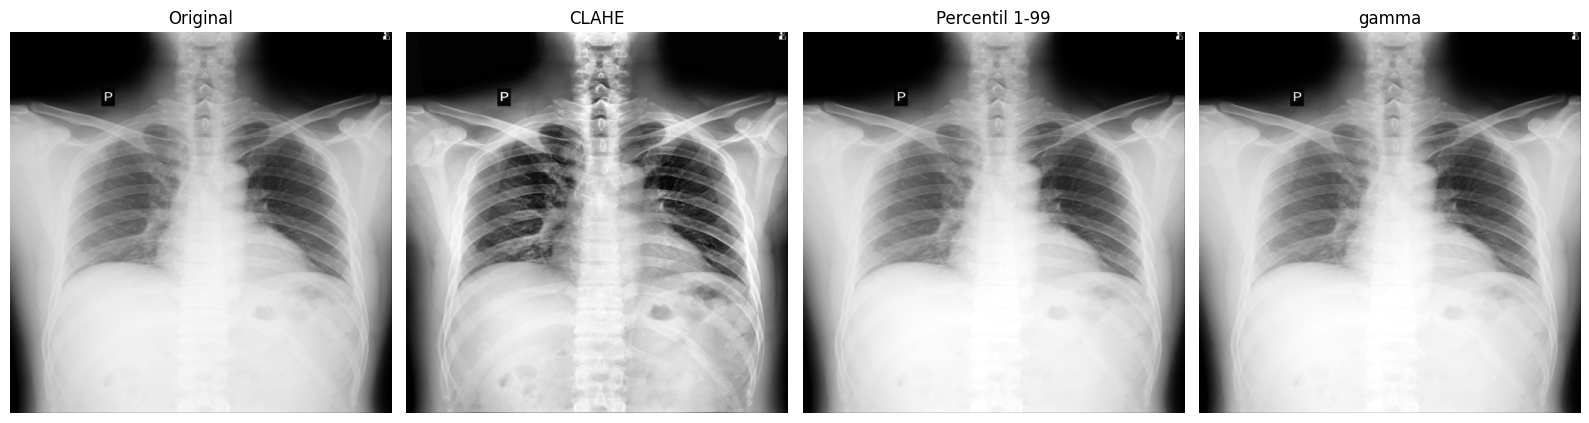

In [46]:
import matplotlib.pyplot as plt

sample_id = classification_df['image_id'].iloc[0]
sample_path = TRAIN_IMG_512 / f"{sample_id}.png"

orig = cv.imread(str(sample_path), cv.IMREAD_GRAYSCALE)
clahe_img = apply_clahe(orig, clip_limit=3.0, tile_grid_size=(8, 8))
percentile_img = apply_percentile_clip(orig, low_percentile=1, high_percentile=99)
gamma_img = gamma_correction(orig, 1.2)

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
axes[0].imshow(orig, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(clahe_img, cmap='gray')
axes[1].set_title('CLAHE')
axes[1].axis('off')
axes[2].imshow(percentile_img, cmap='gray')
axes[2].set_title('Percentil 1-99')
axes[2].axis('off')
axes[3].imshow(percentile_img, cmap='gray')
axes[3].set_title('gamma')
axes[3].axis('off')
plt.tight_layout()
plt.show()

In [47]:
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

target_cols = [f"class_{i}" for i in range(14)]

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42,
)

X = classification_df[["image_id"]].values
y = classification_df[target_cols].values

train_idx, val_idx = next(msss.split(X, y))

train_df = classification_df.iloc[train_idx].reset_index(drop=True)
val_df = classification_df.iloc[val_idx].reset_index(drop=True)

print(f"Total images:      {len(classification_df)}")
print(f"Training images:   {len(train_df)}")
print(f"Validation images: {len(val_df)}")

comparison = pd.DataFrame({
    "train_pct": train_df[target_cols].mean(),
    "val_pct": val_df[target_cols].mean(),
})
print(comparison)

Total images:      8573
Training images:   6858
Validation images: 1715
          train_pct   val_pct
class_0    0.275882  0.275802
class_1    0.019539  0.019242
class_2    0.044911  0.044898
class_3    0.203704  0.203499
class_4    0.037912  0.037901
class_5    0.039808  0.039650
class_6    0.062117  0.061808
class_7    0.132108  0.131778
class_8    0.082240  0.082216
class_9    0.112569  0.112536
class_10   0.106008  0.106122
class_11   0.196996  0.197085
class_12   0.009186  0.009329
class_13   0.161855  0.162099


In [48]:
import torch.optim as optim
from pathlib import Path

# Configuration 
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 4



CLAHE_CLIP_LIMIT = 2.0       # 4.0 more contrast, 2.0 if noise appears
CLAHE_TILE_GRID = (8, 8)     # size local regions for CLAHE
PERCENTILE_LOW = 1               
PERCENTILE_HIGH = 99
GAMMA = 1.2

# Initialize Data Components 
train_dataset = ChestXrayDataset(
    train_df,
    TRAIN_IMG_512_BORDER,
    contrast_method=None,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid=CLAHE_TILE_GRID,
    percentile_low=PERCENTILE_LOW,
    percentile_high=PERCENTILE_HIGH,
    gamma=GAMMA,
    transform=train_transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

val_dataset = ChestXrayDataset(
    val_df,
    TRAIN_IMG_512_BORDER,
    contrast_method=None,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid=CLAHE_TILE_GRID,
    percentile_low=PERCENTILE_LOW,
    percentile_high=PERCENTILE_HIGH,
    gamma=GAMMA
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
# # --- Initialize Model Core ---
# model = ChestXrayClassifier(num_classes=14)
# model.to(DEVICE)

# --- Define Optimization Functions ---
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)


In [49]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score
)

CLASS_NAMES = [
    'Aortic enlargement', 
    'Atelectasis', 
    'Calcification', 
    'Cardiomegaly',
    'Consolidation', 
    'ILD', 
    'Infiltration', 
    'Lung Opacity',
    'Nodule/Mass', 
    'Other lesion', 
    'Pleural effusion', 
    'Pleural thickening',
    'Pneumothorax', 
    'Pulmonary fibrosis'
    #No Finding
]
THRESHOLD = 0.5

def calculate_metrics(y_true, y_prob, threshold=0.5):

    roc_auc = {}
    pr_auc = {}

    # Calculate metrics for every class
    for i, class_name in enumerate(CLASS_NAMES):

        y_true_class = y_true[:, i]
        y_prob_class = y_prob[:, i]

        # ROC-AUC
        if len(np.unique(y_true_class)) > 1:
            roc_auc[class_name] = roc_auc_score(
                y_true_class,
                y_prob_class
            )
        else:
            roc_auc[class_name] = np.nan

        # PR-AUC
        if y_true_class.sum() > 0:
            pr_auc[class_name] = average_precision_score(
                y_true_class,
                y_prob_class
            )
        else:
            pr_auc[class_name] = np.nan


    # Macro metrics
    macro_roc_auc = np.nanmean(
        list(roc_auc.values())
    )

    macro_pr_auc = np.nanmean(
        list(pr_auc.values())
    )

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "macro_roc_auc": macro_roc_auc,
        "macro_pr_auc": macro_pr_auc,
    }

def train_model(model, train_loader, epoch):

    model.train()
    train_loss = 0.0
    
    print(f"TRAINING Epoch {epoch + 1}/{EPOCHS}")

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        train_loss += loss.item()

    # Average training loss
    train_loss /= len(train_loader)
    return train_loss


def validate_model(model, val_loader, epoch):
    """ 
    Validates the model and returns: 
        - All labels (ndarray)
        - All probabilities (ndarray)
        - validation loss function value
    """

    model.eval()

    val_loss = 0.0

    all_labels = []
    all_probs = []

    print(f"VALIDATING Epoch {epoch + 1}/{EPOCHS}")
    
    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            # Forward pass
            outputs = model(images)

            # Validation loss
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            # Convert logits to probabilities
            probs = torch.sigmoid(outputs)

            # Store labels and probabilities
            all_labels.append(
                labels.cpu().numpy()
            )

            all_probs.append(
                probs.cpu().numpy()
            )
            
    # Average validation loss
    val_loss /= len(val_loader)

    # Combine all validation batches
    all_labels = np.concatenate(
        all_labels,
        axis=0
    )

    all_probs = np.concatenate(
        all_probs,
        axis=0
    )
    return all_labels, all_probs, val_loss

def save_and_print_metrics(history, per_class_history, epoch, train_loss, val_loss, metrics):

    # save global metrics
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "macro_roc_auc": metrics["macro_roc_auc"],
        "macro_pr_auc": metrics["macro_pr_auc"],
    })

    # save pre-class metrics
    for class_name in CLASS_NAMES:

        per_class_history.append({
            "epoch": epoch + 1,
            "class": class_name,
            "roc_auc": metrics["roc_auc"][class_name],
            "pr_auc": metrics["pr_auc"][class_name],
        })


Train the model:
- Using BCEWithLogitsLoss 
    - because high class imbalance in our training data.
- AdamW optimizer

We use the loss function in the validation set to decide wich model we are keeping.

In [50]:
import time

history = []
per_class_history = []

patience = 3
epochs_without_improvement = 0

best_val_loss = float("inf")
best_pr_auc = -float("inf")

best_epoch = None

for epoch in range(EPOCHS):

    epoch_start = time.time()

    # TRAIN
    train_loss = train_model(model, train_loader, epoch)

    # VALIDATION
    all_labels, all_probs, val_loss = validate_model(model, val_loader, epoch)

    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch + 1} duration: {epoch_time:.1f}s")
    
    # calculate metrics
    metrics = calculate_metrics(
        all_labels,
        all_probs,
        threshold=THRESHOLD
    )

    # save global metrics
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "macro_roc_auc": metrics["macro_roc_auc"],
        "macro_pr_auc": metrics["macro_pr_auc"],
    })
    # save pre-class metrics
    for class_name in CLASS_NAMES:

        per_class_history.append({
            "epoch": epoch + 1,
            "class": class_name,
            "roc_auc": metrics["roc_auc"][class_name],
            "pr_auc": metrics["pr_auc"][class_name],
        })

    current_pr_auc = metrics["macro_pr_auc"]

    # save best model
    if best_pr_auc < current_pr_auc:

        best_pr_auc = current_pr_auc
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            f"models/best_model_{MODEL_NAME}.pth"
        )
        best_model_message = " <-- Best model"

    else:
     
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch {epoch + 1}"
        )
        print(
            f"Best epoch: {best_epoch}"
        )

        break

    # print results
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(
        f"Macro ROC-AUC: "
        f"{metrics['macro_roc_auc']:.4f}"
    )
    print(
        f"Macro PR-AUC:  "
        f"{metrics['macro_pr_auc']:.4f}"
    )

    print("Per class metrics:")
    print(per_class_history)
    print(best_model_message)


# SAVE RESULTS AS DATAFRAMES
history_df = pd.DataFrame(history)

per_class_history_df = pd.DataFrame(
    per_class_history
)

history_df.to_csv(
    f"models/training_metrics_model_{MODEL_NAME}.csv",
    index=False
)

per_class_history_df.to_csv(
    f"models/per_class_training_metrics_model_{MODEL_NAME}.csv",
    index=False
)

#get best epoch
best_epoch_metrics = history_df[
    history_df["epoch"] == best_epoch
].iloc[0]


# SHOW GLOBAL METRICS
print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Best epoch:      {best_epoch}")
print(f"Val Loss:   {best_epoch_metrics['val_loss']:.4f}")
print(f"Macro ROC-AUC:   {best_epoch_metrics['macro_roc_auc']:.4f}")
print(f"Macro PR-AUC:    {best_epoch_metrics['macro_pr_auc']:.4f}")


# SHOW FINAL PER-CLASS METRICS

final_metrics_df = (
    per_class_history_df[
        per_class_history_df["epoch"] == best_epoch
    ]
    .drop(columns=["epoch"])
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("PER-CLASS METRICS OF BEST MODEL")
print("=" * 70)

print(
    final_metrics_df.to_string(index=False)
)

TRAINING Epoch 1/20
VALIDATING Epoch 1/20
Epoch 1 duration: 702.5s

Epoch 1/20
Train Loss: 0.2632
Val Loss:   0.2051
Macro ROC-AUC: 0.8775
Macro PR-AUC:  0.3697
Per class metrics:
[{'epoch': 1, 'class': 'Aortic enlargement', 'roc_auc': 0.9272860046368642, 'pr_auc': 0.7983875462443225}, {'epoch': 1, 'class': 'Atelectasis', 'roc_auc': 0.9076676395344647, 'pr_auc': 0.17381055553903418}, {'epoch': 1, 'class': 'Calcification', 'roc_auc': 0.8248259676831106, 'pr_auc': 0.13509302093097897}, {'epoch': 1, 'class': 'Cardiomegaly', 'roc_auc': 0.9130143853805267, 'pr_auc': 0.7240777748107919}, {'epoch': 1, 'class': 'Consolidation', 'roc_auc': 0.8747132867132867, 'pr_auc': 0.21193151902878887}, {'epoch': 1, 'class': 'ILD', 'roc_auc': 0.8581377906353799, 'pr_auc': 0.1707786711952075}, {'epoch': 1, 'class': 'Infiltration', 'roc_auc': 0.8623954876461415, 'pr_auc': 0.24279676479082504}, {'epoch': 1, 'class': 'Lung Opacity', 'roc_auc': 0.8791432154382878, 'pr_auc': 0.46857374897085846}, {'epoch': 1, 'cl

In [57]:
from sklearn.metrics import confusion_matrix

def compute_optim_thresholds_f1(all_labels, all_probs):

    thresholds = np.arange(0.01, 1.00, 0.01)

    f1_thresholds = []
    f1_only_th = []

    for i, class_name in enumerate(CLASS_NAMES):

        opt_f1 = -1.0
        best_result = None

        y_true = all_labels[:, i]
        y_prob = all_probs[:, i]

        for threshold in thresholds:

            y_pred = (y_prob >= threshold).astype(int)

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()

            sensitivity = (
                tp / (tp + fn)
                if (tp + fn) > 0
                else 0.0
            )

            precision = (
                tp / (tp + fp)
                if (tp + fp) > 0
                else 0.0
            )

            specificity = (
                tn / (tn + fp)
                if (tn + fp) > 0
                else 0.0
            )

            fpr = (
                fp / (fp + tn)
                if (fp + tn) > 0
                else 0.0
            )

            f1 = (
                2 * precision * sensitivity /
                (precision + sensitivity)
                if (precision + sensitivity) > 0
                else 0.0
            )

            if f1 > opt_f1:

                best_result = {
                    "class": class_name,
                    "threshold": threshold,
                    "TP": tp,
                    "TN": tn,
                    "FP": fp,
                    "FN": fn,
                    "Precision": precision,
                    "Recall": sensitivity,
                    "Sensitivity": sensitivity,
                    "Specificity": specificity,
                    "FPR": fpr,
                    "F1": f1,
                    "threshold_found": True
                }

                opt_f1 = f1

        f1_thresholds.append(best_result)
        f1_only_th.append(best_result["threshold"])

    return pd.DataFrame(f1_thresholds), f1_only_th

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np


def calculate_metrics_wthresholds(y_true, y_prob, thresholds):

    roc_auc = {}
    pr_auc = {}
    precision = {}
    recall = {}
    sensitivity = {}
    f1 = {}

    # Calculate metrics for every class
    for i, class_name in enumerate(CLASS_NAMES):

        y_true_class = y_true[:, i]
        y_prob_class = y_prob[:, i]

        if len(np.unique(y_true_class)) > 1:

            roc_auc[class_name] = roc_auc_score(
                y_true_class,
                y_prob_class
            )

        else:

            roc_auc[class_name] = np.nan

        if y_true_class.sum() > 0:

            pr_auc[class_name] = average_precision_score(
                y_true_class,
                y_prob_class
            )

        else:

            pr_auc[class_name] = np.nan

        threshold = thresholds[i]

        y_pred_class = (
            y_prob_class >= threshold
        ).astype(int)

        precision[class_name] = precision_score(
            y_true_class,
            y_pred_class,
            zero_division=0
        )

        recall[class_name] = recall_score(
            y_true_class,
            y_pred_class,
            zero_division=0
        )

        sensitivity[class_name] = recall[class_name]

        f1[class_name] = f1_score(
            y_true_class,
            y_pred_class,
            zero_division=0
        )


    macro_roc_auc = np.nanmean(
        list(roc_auc.values())
    )

    macro_pr_auc = np.nanmean(
        list(pr_auc.values())
    )

    macro_precision = np.nanmean(
        list(precision.values())
    )

    macro_recall = np.nanmean(
        list(recall.values())
    )

    macro_sensitivity = np.nanmean(
        list(sensitivity.values())
    )

    macro_f1 = np.nanmean(
        list(f1.values())
    )

    return {

        "roc_auc": roc_auc,
        "pr_auc": pr_auc,

        "precision": precision,
        "recall": recall,
        "sensitivity": sensitivity,
        "f1": f1,

        "macro_roc_auc": macro_roc_auc,
        "macro_pr_auc": macro_pr_auc,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_sensitivity": macro_sensitivity,
        "macro_f1": macro_f1,
    }

In [58]:
def split_validation_50_50(validation_df, target_cols):

    msss = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=0.5,
        random_state=42,
    )

    X = validation_df[["image_id"]].values
    y = validation_df[target_cols].values

    threshold_idx, evaluation_idx = next(
        msss.split(X, y)
    )

    threshold_df = validation_df.iloc[threshold_idx].copy()
    evaluation_df = validation_df.iloc[evaluation_idx].copy()

    print(f"Total images:      {len(validation_df)}")
    print(f"Training images:   {len(threshold_df)}")
    print(f"Validation images: {len(evaluation_df)}")

    comparison = pd.DataFrame({
        "threshold_pct": threshold_df[target_cols].mean(),
        "evaluation_pct": evaluation_df[target_cols].mean(),
    })
    print(comparison)
    return threshold_df, evaluation_df



threshold_df, evaluation_df = split_validation_50_50(val_df, target_cols)

threshold_dataset = ChestXrayDataset(
    threshold_df,
    TRAIN_IMG_512,
    contrast_method=None,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid=CLAHE_TILE_GRID,
    percentile_low=PERCENTILE_LOW,
    percentile_high=PERCENTILE_HIGH,
    gamma=GAMMA
)
threshold_loader = DataLoader(
    threshold_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

evaluation_dataset = ChestXrayDataset(
    evaluation_df,
    TRAIN_IMG_512,
    contrast_method=None,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid=CLAHE_TILE_GRID,
    percentile_low=PERCENTILE_LOW,
    percentile_high=PERCENTILE_HIGH,
    gamma=GAMMA
)
evaluation_loader = DataLoader(
    evaluation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Total images:      1715
Training images:   857
Validation images: 858
          threshold_pct  evaluation_pct
class_0        0.275379        0.276224
class_1        0.018670        0.019814
class_2        0.044341        0.045455
class_3        0.203034        0.203963
class_4        0.037340        0.038462
class_5        0.039673        0.039627
class_6        0.061844        0.061772
class_7        0.131855        0.131702
class_8        0.081680        0.082751
class_9        0.112019        0.113054
class_10       0.106184        0.106061
class_11       0.197200        0.196970
class_12       0.009335        0.009324
class_13       0.162194        0.162005


In [59]:
model.load_state_dict(
    torch.load(
        r"models\best_model_efficientnet_b4_augmentation-affine-contrastpercentile-gaussnoise.pth",
        map_location=DEVICE
    )
)

model.to(DEVICE)

all_labels, all_probs, val_loss = validate_model(model, threshold_loader, 0)
info_df, thresholds = compute_optim_thresholds_f1(all_labels, all_probs)

all_labels, all_probs, val_loss = validate_model(model, evaluation_loader, 0)
metrics_bestmodel = calculate_metrics_wthresholds(all_labels, all_probs, thresholds)
pd.DataFrame(metrics_bestmodel)

VALIDATING Epoch 1/20
VALIDATING Epoch 1/20


,roc_auc,pr_auc,precision,recall,sensitivity,f1,macro_roc_auc,macro_pr_auc,macro_precision,macro_recall,macro_sensitivity,macro_f1
Aortic enlargement,0.969234,0.918368,0.796226,0.890295,0.890295,0.840637,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
Atelectasis,0.940967,0.532529,0.800000,0.470588,0.470588,0.592593,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
Calcification,0.917535,0.543614,0.586207,0.435897,0.435897,0.500000,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
Cardiomegaly,0.975662,0.930286,0.701299,0.925714,0.925714,0.798030,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
Consolidation,0.935574,0.529399,0.615385,0.484848,0.484848,0.542373,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
ILD,0.953955,0.551939,0.517241,0.441176,0.441176,0.476190,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
Infiltration,0.954342,0.631646,0.369748,0.830189,0.830189,0.511628,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
Lung Opacity,0.929334,0.709582,0.509434,0.716814,0.716814,0.595588,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
Nodule/Mass,0.908245,0.519930,0.632653,0.436620,0.436620,0.516667,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971
Other lesion,0.871290,0.440607,0.303502,0.804124,0.804124,0.440678,0.935239,0.651009,0.597448,0.650636,0.650636,0.595971


In [ ]:

def plot_metric_vs_baseline(baseline_df, model_df, metric, model_name="Model", figsize=(14, 6)):

    if metric not in baseline_df.columns:
        raise ValueError(f"Metric '{metric}' not found in baseline_df.")

    if metric not in model_df.columns:
        raise ValueError(f"Metric '{metric}' not found in model_df.")

    baseline = baseline_df.drop(index="Macro", errors="ignore")
    model = model_df.drop(index="Macro", errors="ignore")
    
    common_classes = baseline.index.intersection(model.index)
    baseline_values = baseline.loc[common_classes, metric].astype(float)
    model_values = model.loc[common_classes, metric].astype(float)
    improvement = model_values - baseline_values

    x = np.arange(len(common_classes))
    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(
        y=0,
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label="Baseline"
    )
    ax.plot(
        x,
        improvement,
        linewidth=0.8,
        alpha=0.6
    )
    ax.scatter(
        x,
        improvement,
        s=45,
        label=model_name,
        zorder=3
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        common_classes,
        rotation=60,
        ha="right",
        fontsize=11
    )
    ax.tick_params(axis="y", labelsize=11)
    metric_name = metric.replace("_", "-").upper()
    ax.set_xlabel("Class", fontsize=13)
    ax.set_ylabel(
        f"Δ {metric_name} relative to baseline",
        fontsize=13
    )
    ax.set_title(
        f"Per-class {metric_name} improvement relative to baseline",
        fontsize=15,
        pad=12
    )
    max_abs = np.abs(improvement).max()
    margin = max(max_abs * 0.15, 0.01)
    ax.set_ylim(
        improvement.min() - margin,
        improvement.max() + margin
    )
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_metric_vs_baseline(metrics_baseline, metrics_bestmodel, "precision", "Best model")

plot_metric_vs_baseline(metrics_baseline, metrics_bestmodel, "recall", "Best model")

plot_metric_vs_baseline(metrics_baseline, metrics_bestmodel, "f1", "Best model")

plot_metric_vs_baseline(metrics_baseline, metrics_bestmodel, "pr_auc", "Best model")

plot_metric_vs_baseline(metrics_baseline, metrics_bestmodel, "roc_auc", "Best model")


Trying to implement GradCam

In [70]:

class GradCAM:
    def __init__(self, model, target_layer=None):
        self.model = model
        self.model.eval()
        self.activations = None
        self.gradients = None

        if target_layer is not None:
            self.target_layer = target_layer
        else:
            self.target_layer = None
            for module in self.model.modules():
                if isinstance(module, torch.nn.Conv2d):
                    self.target_layer = module
            if self.target_layer is None:
                raise RuntimeError("No Conv2d layer found in the model.")

        self.forward_hook = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        target = output[:, class_idx]
        target.backward(torch.ones_like(target))

        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam.squeeze(0)  # ok para batch_size=1

        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam.cpu().numpy()

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

In [71]:
import torch.nn.functional as F
import matplotlib.patches as patches

model.load_state_dict(
    torch.load(
        r"models\best_model_efficientnet_b4_augmentation-affine-contrastpercentile-gaussnoise.pth",
        map_location=DEVICE
    )
)
model.to(DEVICE)

gradcam = GradCAM(model, target_layer=model.backbone.conv_head)


def denormalize(image_tensor):
    """Deshace la normalización ImageNet para poder visualizar la imagen."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = image_tensor.cpu().numpy().transpose(1, 2, 0)  # CHW -> HWC
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

def scale_bounding_box(image_id, img_size_df, x_min, y_min, x_max, y_max, target_size=1024):

    # dim_0 = img_size_df[img_size_df['image_id'] == image_id]['dim0']
    # dim_1 = img_size_df[img_size_df['image_id'] == image_id]['dim1']

    row = img_size_df.loc[img_size_df['image_id'] == image_id]
    height = row['dim0'].iloc[0]
    width = row['dim1'].iloc[0]
    
    x_min = (x_min / width) * target_size
    x_max = (x_max / width) * target_size
    y_min = (y_min / height) * target_size
    y_max = (y_max / height) * target_size

    return x_min, y_min, x_max, y_max

def draw_bboxes(ax, image_id, df, img_size_df, only_class_name=None):
 
    ax.autoscale(False)  # evita que las cajas re-escalen los ejes
    rows = df[df['image_id'] == image_id]
    colors = plt.cm.tab20.colors

    for _, r in rows.iterrows():
        if r['class_name'] == 'No finding':
            continue
        if only_class_name is not None and r['class_name'] != only_class_name:
            continue

        cid = int(r['class_id'])
        color = colors[cid % 20]
        x_min, y_min, x_max, y_max = scale_bounding_box(
            image_id, img_size_df, r['x_min'], r['y_min'], r['x_max'], r['y_max']
        )
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min, y_max - y_min,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x_min + 4, y_min + 20,
            f"{r['class_name']} ({r['rad_id']})",
            fontsize=9, color='white', fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'),
            clip_on=True
        )

# def show_sample(image_id, df, img_dir, ax, img_size_df):
#     img_path = img_dir / f'{image_id}.png'
#     img = cv.imread(str(img_path))
#     if img is None:
#         ax.text(0.5, 0.5, 'Not found', ha='center', va='center', transform=ax.transAxes)
#         ax.axis('off')
#         return

#     img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
#     ax.imshow(img)
#     draw_bboxes(ax, image_id, df, img_size_df)
#     ax.axis('off')
#     ax.set_title(image_id[:12], fontsize=10, pad=4)

def show_gradcam(dataset, idx, class_idx, gradcam, bbox_df=None, img_size_df=None, alpha=0.4):
    image_tensor, label = dataset[idx]
    image_id = dataset.image_ids[idx]  # ChestXrayDataset ya guarda esto
    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    cam = gradcam.generate(input_tensor, class_idx)

    H, W = image_tensor.shape[1], image_tensor.shape[2]
    cam_resized = cv.resize(cam, (W, H))

    heatmap = cv.applyColorMap((cam_resized * 255).astype(np.uint8), cv.COLORMAP_JET)
    heatmap = cv.cvtColor(heatmap, cv.COLOR_BGR2RGB)

    original = denormalize(image_tensor)
    overlay = (original * (1 - alpha) + heatmap * alpha).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[1].imshow(heatmap)
    axes[1].set_title(f"Grad-CAM: {CLASS_NAMES[class_idx]}")
    axes[2].imshow(overlay)
    axes[2].set_title("Overlay + GT box" if bbox_df is not None else "Overlay")

    if bbox_df is not None and img_size_df is not None:
        target_class_name = CLASS_NAMES[class_idx]
        draw_bboxes(axes[0], image_id, bbox_df, img_size_df, only_class_name=target_class_name)
        draw_bboxes(axes[2], image_id, bbox_df, img_size_df, only_class_name=target_class_name)

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return cam_resized, label

In [ ]:
model.load_state_dict(
    torch.load(
        r"models\best_model_efficientnet_b4_augmentation-affine-contrastpercentile-gaussnoise.pth",
        map_location=DEVICE
    )
)

model.to(DEVICE)
all_labels, all_probs, val_loss = validate_model(model, val_loader, 0)
# CLASS_NAMES = [
#     'Aortic enlargement', 
#     'Atelectasis', 
#     'Calcification', 
#     'Cardiomegaly',
#     'Consolidation', 
#     'ILD', 
#     'Infiltration', 
#     'Lung Opacity',
#     'Nodule/Mass', 
#     'Other lesion', 
#     'Pleural effusion', 
#     'Pleural thickening',
#     'Pneumothorax', 
#     'Pulmonary fibrosis'
#     #No Finding
# ]
train_df = pd.read_csv(TRAIN_CSV_PATH)
img_size_df  = pd.read_csv(IMG_SIZE_CSV_PATH)

VALIDATING Epoch 1/20


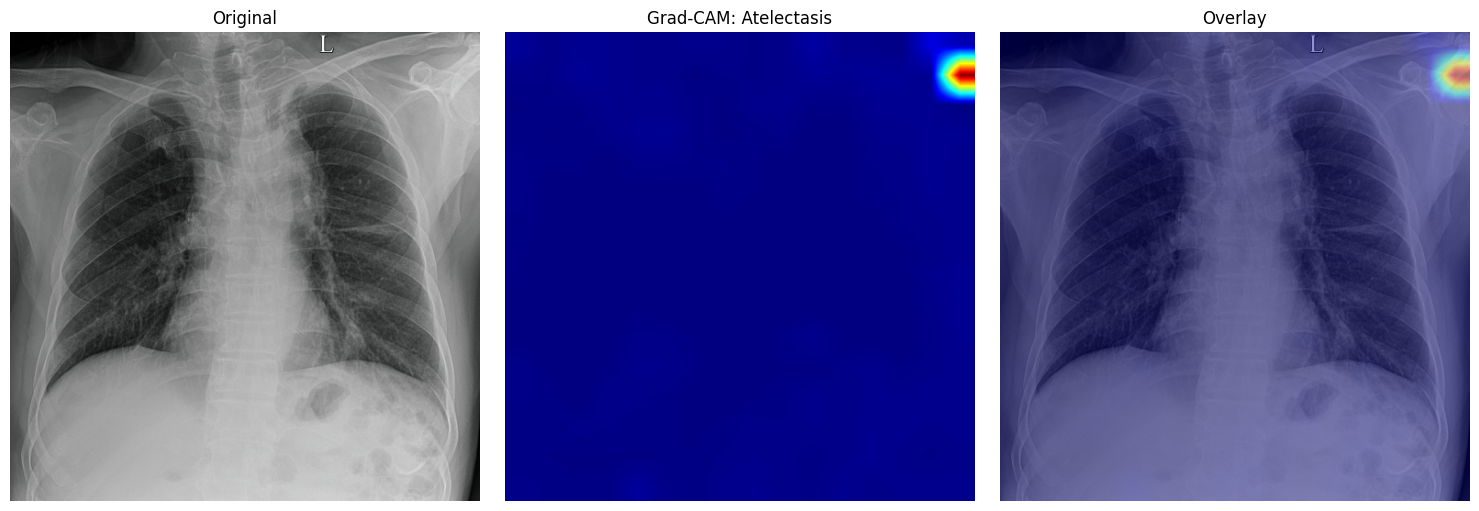

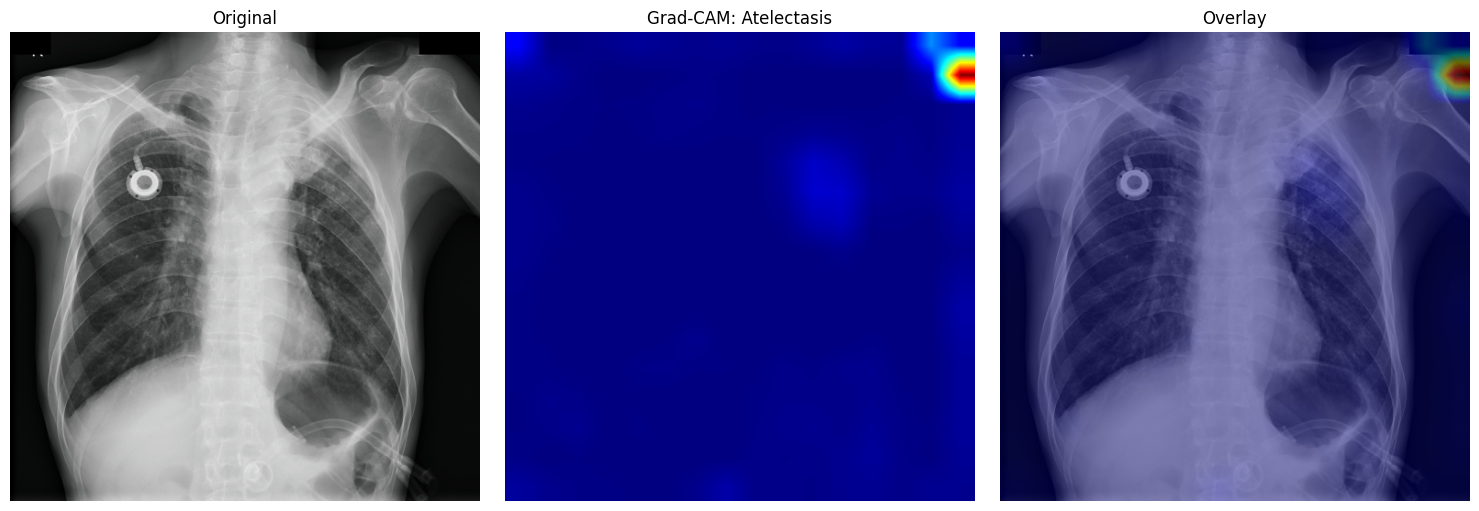

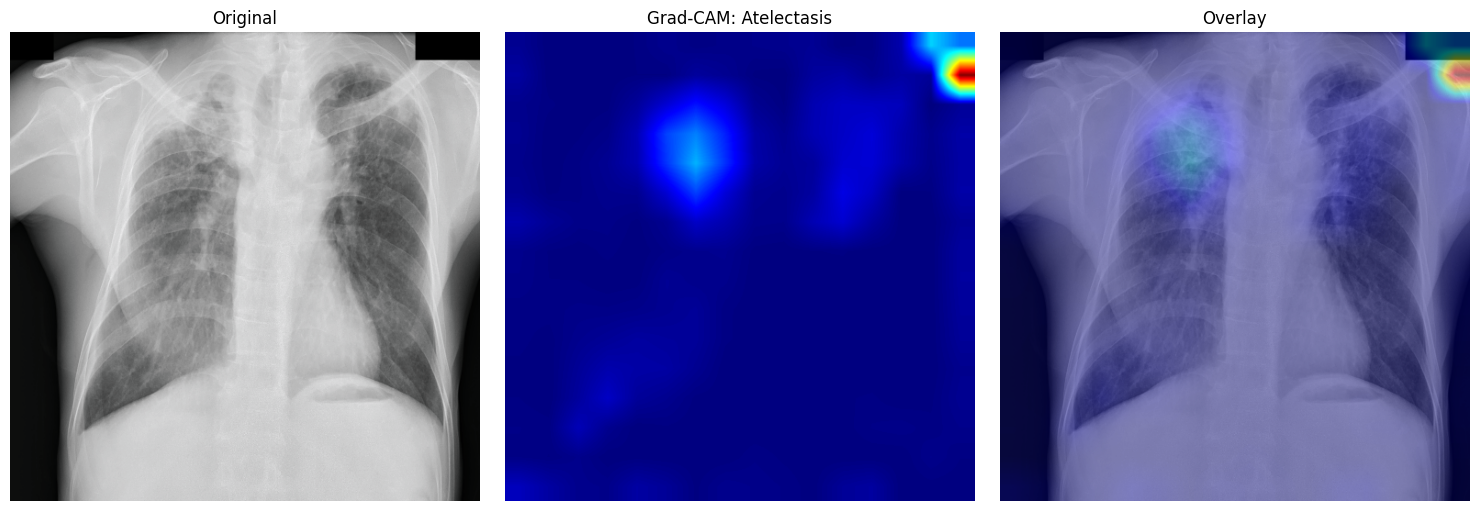

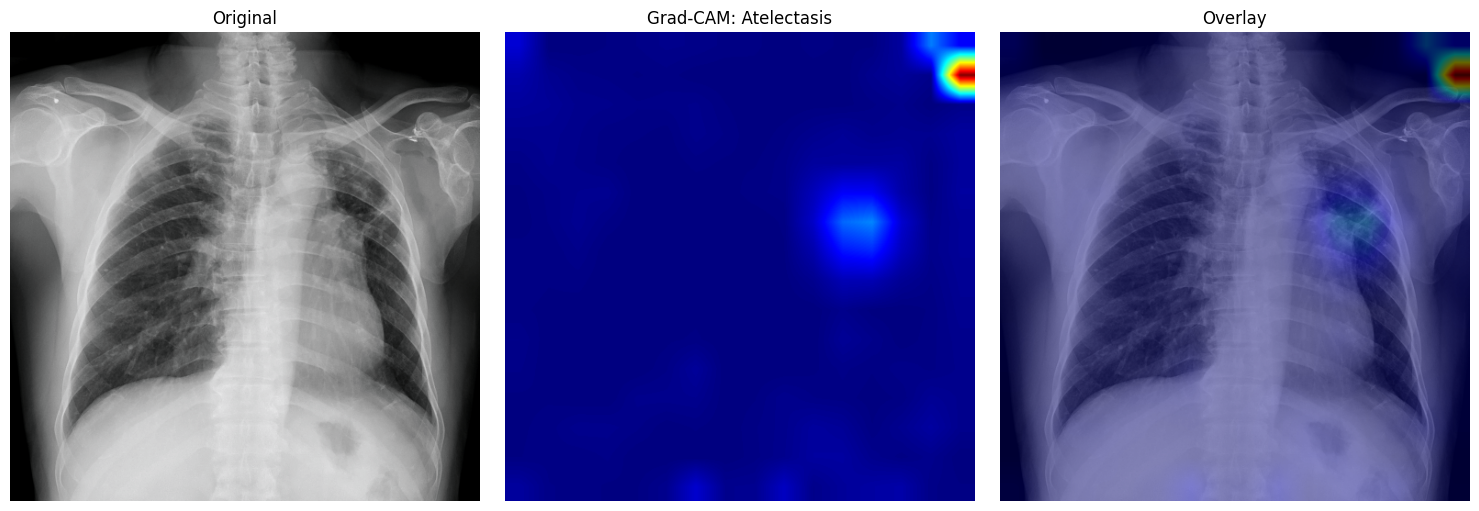

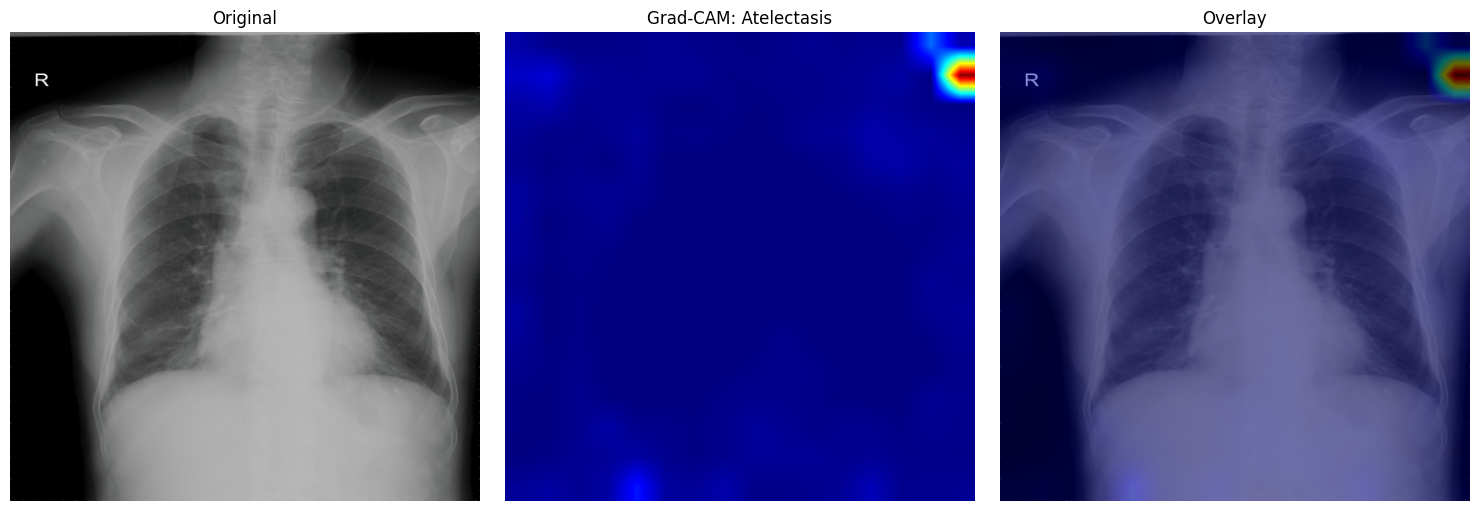

In [ ]:
# dataset SIN augmentation aleatoria, pero CON el mismo preprocessing usado en train/val
eval_dataset = ChestXrayDataset(
    val_df,
    TRAIN_IMG_512,
    contrast_method=None,   # mismo que usaste en val_dataset
    transform=None,
)

class_idx = CLASS_NAMES.index("Atelectasis")  # la clase que quieres inspeccionar

# encuentra índices donde esa clase es positiva en las etiquetas reales
positive_indices = np.where(val_df[f"class_{class_idx}"].values == 1)[0]

for idx in positive_indices[:5]:  # inspecciona las primeras 5
    show_gradcam(eval_dataset, idx, class_idx, gradcam, bbox_df=annotations_df, img_size_df=img_size_df)

In [65]:
def compute_average_gradcam(dataset, indices, class_idx, gradcam, target_size=None):

    cams = []
    for idx in indices:
        image_tensor, _ = dataset[idx]
        input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

        cam = gradcam.generate(input_tensor, class_idx)

        if target_size is None:
            target_size = (image_tensor.shape[2], image_tensor.shape[1])  # (W, H)
        cam_resized = cv.resize(cam, target_size)
        cams.append(cam_resized)

    avg_cam = np.mean(cams, axis=0)

    # renormaliza el promedio a [0,1] para visualizarlo bien
    avg_cam -= avg_cam.min()
    if avg_cam.max() > 0:
        avg_cam /= avg_cam.max()

    return avg_cam, np.array(cams)

def show_average_gradcam(dataset, indices, class_idx, gradcam, max_images=50, alpha=0.45, seed=42):
    rng = np.random.default_rng(seed)
    if len(indices) > max_images:
        indices = rng.choice(indices, max_images, replace=False)

    avg_cam, cams = compute_average_gradcam(dataset, indices, class_idx, gradcam)

    # imagen "media" de fondo, solo para dar contexto visual (no es diagnóstico en sí)
    mean_image = np.mean(
        [denormalize(dataset[idx][0]) for idx in indices], axis=0
    ).astype(np.uint8)

    heatmap = cv.applyColorMap((avg_cam * 255).astype(np.uint8), cv.COLORMAP_JET)
    heatmap = cv.cvtColor(heatmap, cv.COLOR_BGR2RGB)
    overlay = (mean_image * (1 - alpha) + heatmap * alpha).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(mean_image)
    axes[0].set_title(f"Imagen media (n={len(indices)})")
    axes[1].imshow(heatmap)
    axes[1].set_title(f"Grad-CAM promedio: {CLASS_NAMES[class_idx]}")
    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return avg_cam

def split_tp_fn(val_df, all_probs, class_idx, threshold=0.5):
    y_true = val_df[f"class_{class_idx}"].values
    y_prob = all_probs[:, class_idx]
    y_pred = (y_prob >= threshold).astype(int)

    tp_indices = np.where((y_true == 1) & (y_pred == 1))[0]
    fn_indices = np.where((y_true == 1) & (y_pred == 0))[0]
    return tp_indices, fn_indices



VALIDATING Epoch 1/20


TP: 16, FN: 17
Promedio en aciertos (TP):


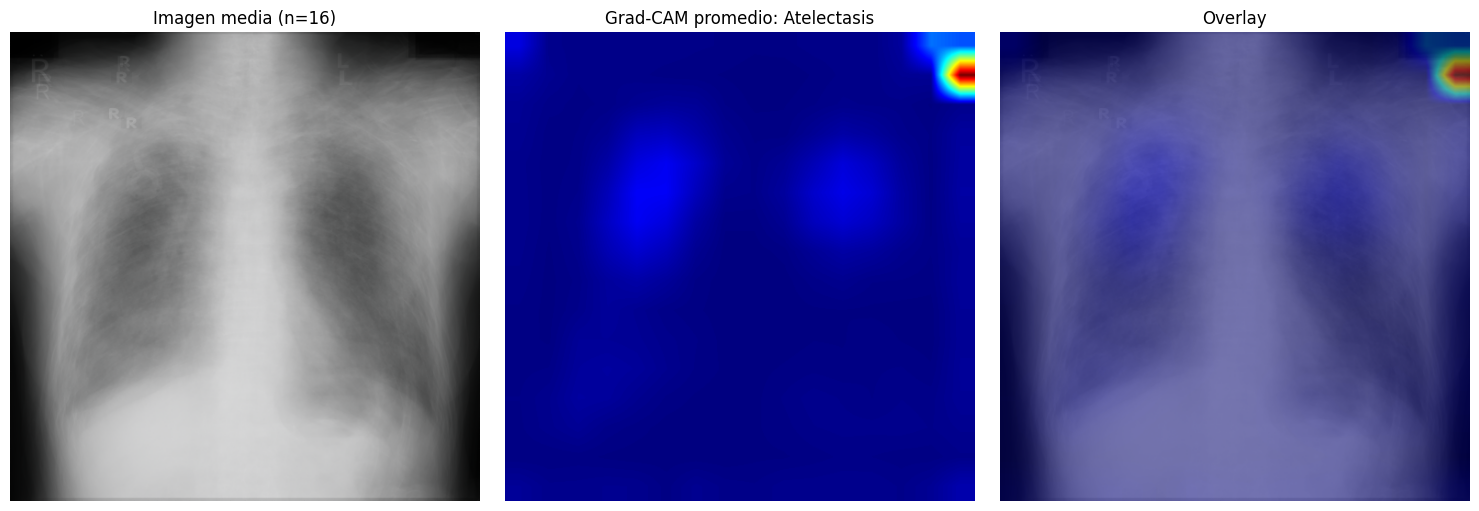

Promedio en fallos (FN):


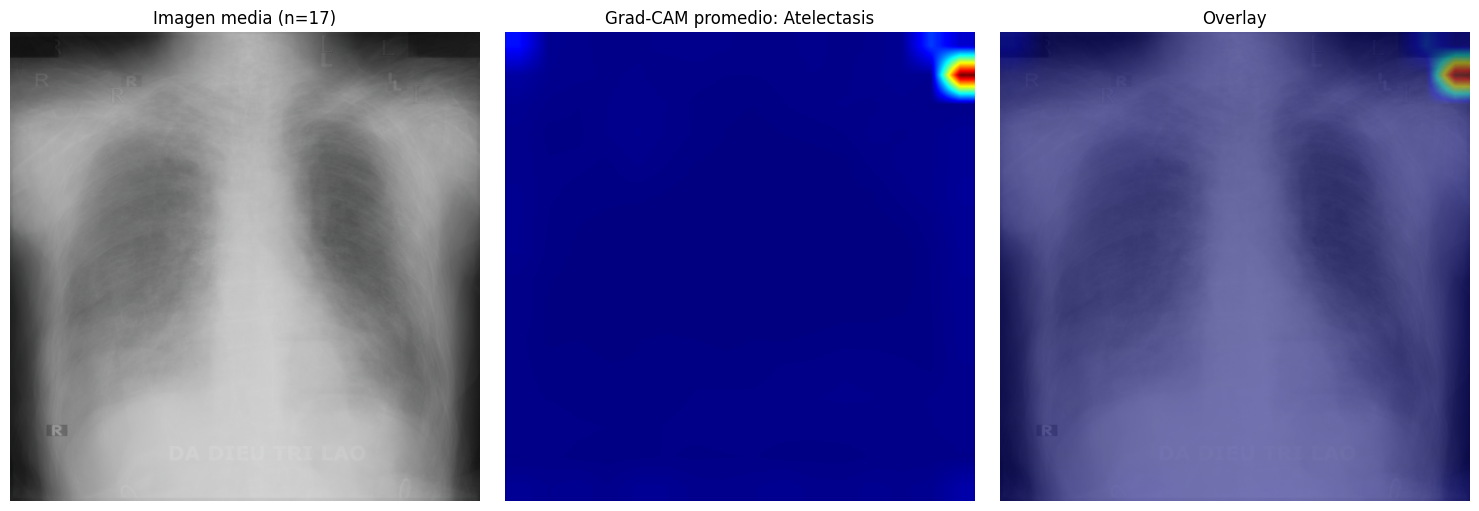

array([[0.13825521, 0.13825521, 0.13825521, ..., 0.0765231 , 0.0765231 ,
        0.0765231 ],
       [0.13825521, 0.13825521, 0.13825521, ..., 0.0765231 , 0.0765231 ,
        0.0765231 ],
       [0.13825521, 0.13825521, 0.13825521, ..., 0.0765231 , 0.0765231 ,
        0.0765231 ],
       ...,
       [0.0220109 , 0.0220109 , 0.0220109 , ..., 0.04012029, 0.04012029,
        0.04012029],
       [0.0220109 , 0.0220109 , 0.0220109 , ..., 0.04012029, 0.04012029,
        0.04012029],
       [0.0220109 , 0.0220109 , 0.0220109 , ..., 0.04012029, 0.04012029,
        0.04012029]], dtype=float32)

In [68]:

class_idx = CLASS_NAMES.index("Atelectasis")  # la clase que quieres inspeccionar

tp_idx, fn_idx = split_tp_fn(val_df, all_probs, class_idx, threshold=THRESHOLD)

print(f"TP: {len(tp_idx)}, FN: {len(fn_idx)}")

print("Promedio en aciertos (TP):")
show_average_gradcam(eval_dataset, tp_idx, class_idx, gradcam)

print("Promedio en fallos (FN):")
show_average_gradcam(eval_dataset, fn_idx, class_idx, gradcam)